In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import random
import gymnasium as gym
import torch
import torch.nn.functional as F
from torch import nn
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import rl_utils

In [2]:
class PolicyNet(torch.nn.Module):
    def __init__(self,state_dim,hidden_dim,action_dim,action_bound):
        super(PolicyNet,self).__init__()
        self.fc1 = torch.nn.Linear(state_dim,hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim,action_dim)
        self.action_bound = action_bound

    def forward(self,x):
        x = F.relu(self.fc1(x))
        return torch.tanh(self.fc2(x)) * self.action_bound
    
class QValueNet(torch.nn.Module):
    def __init__(self,state_dim,hidden_dim,action_dim):
        super(QValueNet,self).__init__()
        self.fc1 = torch.nn.Linear(state_dim+action_dim,hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim,hidden_dim)
        self.fc_out = torch.nn.Linear(hidden_dim,1)

    def forward(self,x,a):
        cat = torch.cat([x,a],dim=1)
        x = F.relu(self.fc1(cat))
        x = F.relu(self.fc2(x))
        return self.fc_out(x)


In [3]:
class DDPG:
    def __init__(self,state_dim,hidden_dim,action_dim,action_bound,sigma,
                 actor_lr,critic_lr,tau,gamma,device):
        self.actor = PolicyNet(state_dim,hidden_dim,action_dim,action_bound).to(device)
        self.critic = QValueNet(state_dim,hidden_dim,action_dim).to(device)

        self.target_actor = PolicyNet(state_dim,hidden_dim,action_dim,action_bound).to(device)
        self.target_critic = QValueNet(state_dim,hidden_dim,action_dim).to(device)
        # initialize same parameters for target net
        self.target_actor.load_state_dict(self.actor.state_dict())
        self.target_critic.load_state_dict(self.critic.state_dict())

        self.actor_optimizer = torch.optim.Adam(self.actor.parameters(), lr=actor_lr)
        self.critic_optimizer = torch.optim.Adam(self.critic.parameters(), lr=critic_lr)

        self.gamma = gamma
        self.sigma = sigma  
        self.tau = tau  
        self.action_dim = action_dim
        self.device = device

    def take_action(self,state):
        # Wrap it with np.array , and add unsqueeze to increase the batch dimension.
        state = torch.tensor(np.array(state), dtype=torch.float32).unsqueeze(0).to(self.device)
        action = self.actor(state).item()
        action = action + self.sigma * np.random.randn(self.action_dim)
        return action
    
    def soft_update(self,net,target_net):
        for param_target,param in zip(target_net.parameters(),net.parameters()):
            param_target.data.copy_(param_target.data * (1.0 - self.tau) + param.data * self.tau)

    def update(self,transition_dict):
        states = torch.tensor(np.array(transition_dict['states']), dtype=torch.float32).to(self.device)
        actions = torch.tensor(np.array(transition_dict['actions']), dtype=torch.float32).view(-1, 1).to(self.device)
        rewards = torch.tensor(np.array(transition_dict['rewards']), dtype=torch.float32).view(-1, 1).to(self.device)
        next_states = torch.tensor(np.array(transition_dict['next_states']), dtype=torch.float32).to(self.device)
        dones = torch.tensor(np.array(transition_dict['dones']), dtype=torch.float32).view(-1, 1).to(self.device)

        next_q_values = self.target_critic(next_states,self.target_actor(next_states)) # why target actor?
        q_target = rewards + self.gamma * next_q_values * (1-dones)
        critic_loss = torch.mean(F.mse_loss(self.critic(states,actions),q_target))
        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()

        actor_loss = -torch.mean(self.critic(states,self.actor(states)))
        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()

        self.soft_update(self.actor,self.target_actor)
        self.soft_update(self.critic,self.target_critic)
        

In [ ]:
actor_lr = 3e-4
critic_lr = 3e-3
num_episodes = 200
hidden_dim = 64
gamma = 0.98
tau = 0.005  # soft update parameter
buffer_size = 10000
minimal_size = 1000
batch_size = 64
sigma = 0.01  # noise std

if torch.cuda.is_available() :
    device = 'cuda'
elif torch.backends.mps.is_available() :
    device = 'mps'
else :
    device = 'cpu'

env_name = 'Pendulum-v1'
env = gym.make(env_name)
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
replay_buffer = rl_utils.ReplayBuffer(buffer_size)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
action_bound = env.action_space.high[0]  # maximum of actions
agent = DDPG(state_dim, hidden_dim, action_dim, action_bound, sigma, actor_lr, critic_lr, tau, gamma, device)

return_list = rl_utils.train_off_policy_agent(env, agent, num_episodes, replay_buffer, minimal_size, batch_size)

Iteration 9: 100%|██████████| 20/20 [00:02<00:00,  6.71it/s, episode=200, return=-9.921]


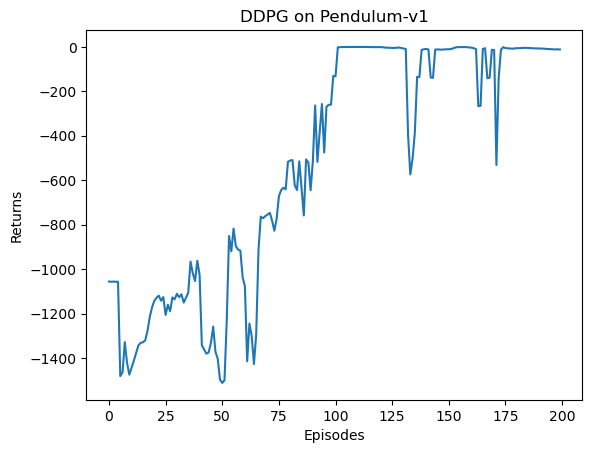

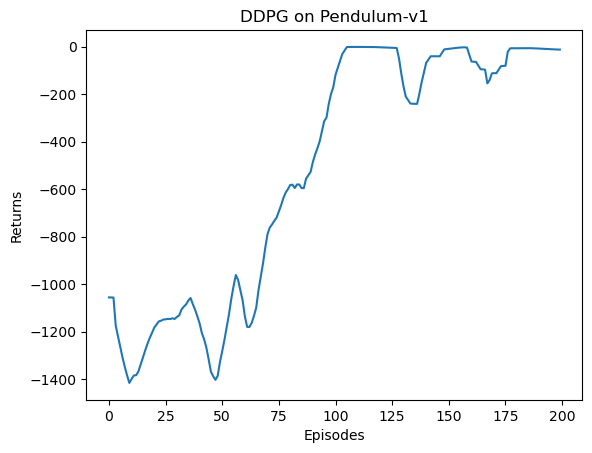

In [5]:
episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('DDPG on {}'.format(env_name))
plt.show()

mv_return = rl_utils.moving_average(return_list, 9)
plt.plot(episodes_list, mv_return)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('DDPG on {}'.format(env_name))
plt.show()

It steadily climbed from -1400 in the early stages, and began to plateau after about 150 episodes, eventually stabilizing in the range of -200 to 0.